In [ ]:
!pip install -q imbalanced-learn joblib

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (891, 15)


In [ ]:
df.to_csv("titanic.csv", index=False)

print("titanic.csv saved successfully.")

titanic.csv saved successfully.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.shape

(891, 15)

In [ ]:
# Calculate missing values
missing_count = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
})

# Show only columns that have missing values
missing_report = missing_report[missing_report["Missing Count"] > 0]

print("Missing Value Report:")
display(missing_report)

Missing Value Report:


,Missing Count,Missing Percentage
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


In [ ]:
# Create a copy for cleaning
clean_df = df.copy()

# 1. Very high missingness: drop deck column
clean_df = clean_df.drop(columns=["deck"])

# 2. Less than 5% missing: drop rows
clean_df = clean_df.dropna(
    subset=["embarked", "embark_town"]
)

# 3. 5%–30% missing: median imputation for age
clean_df["age"] = clean_df["age"].fillna(
    clean_df["age"].median()
)

print("Missing-value handling completed.")

Missing-value handling completed.


In [ ]:
print("Missing values after cleaning:")
print(clean_df.isnull().sum())

Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


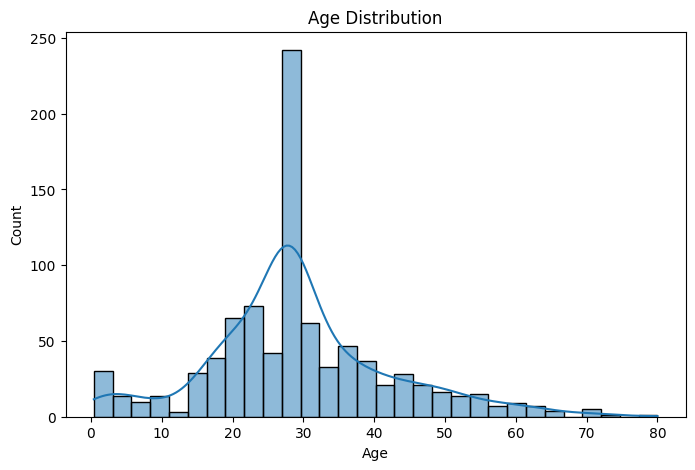

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    clean_df["age"],
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

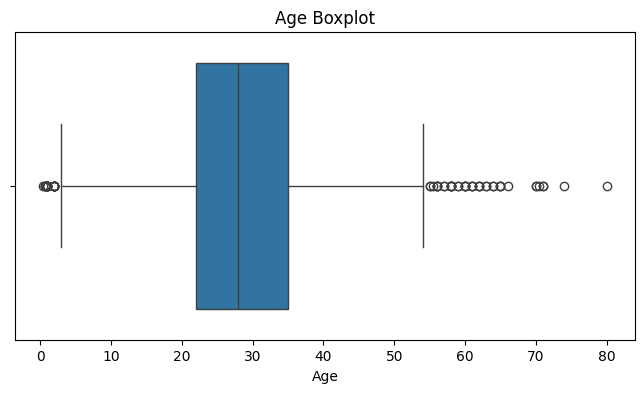

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=clean_df["age"]
)

plt.title("Age Boxplot")
plt.xlabel("Age")

plt.show()

In [ ]:
Q1_age = clean_df["age"].quantile(0.25)
Q3_age = clean_df["age"].quantile(0.75)

IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = clean_df[
    (clean_df["age"] < lower_age) |
    (clean_df["age"] > upper_age)
]

print("Age Q1:", Q1_age)
print("Age Q3:", Q3_age)
print("Age IQR:", IQR_age)
print("Lower bound:", lower_age)
print("Upper bound:", upper_age)
print("Number of age outliers:", len(age_outliers))

Age Q1: 22.0
Age Q3: 35.0
Age IQR: 13.0
Lower bound: 2.5
Upper bound: 54.5
Number of age outliers: 65


Step 1 — Fare histogram

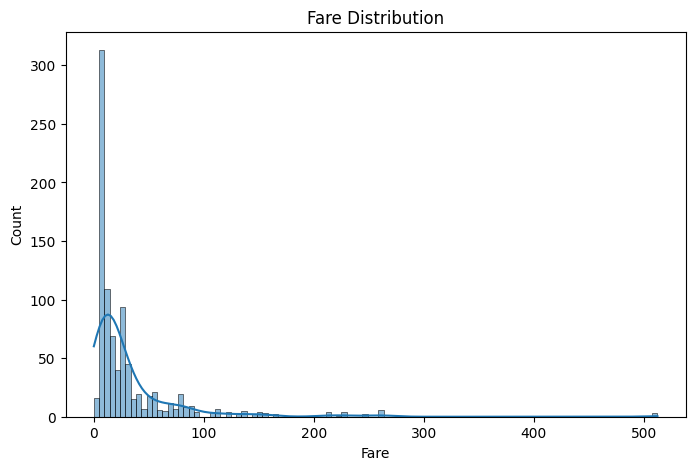

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    clean_df["fare"],
    kde=True
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")

plt.show()

Step 2 — Fare boxplot

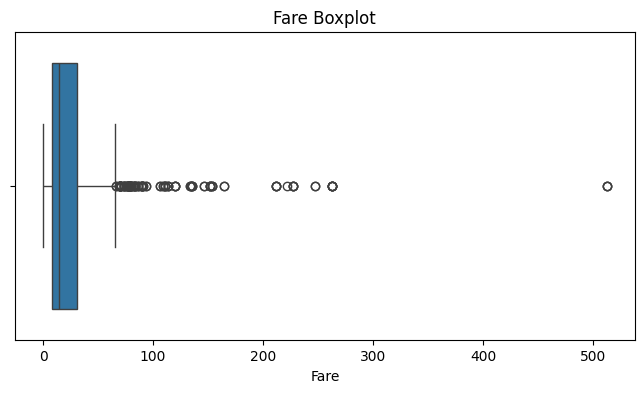

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=clean_df["fare"]
)

plt.title("Fare Boxplot")
plt.xlabel("Fare")

plt.show()

In [ ]:
Q1_fare = clean_df["fare"].quantile(0.25)
Q3_fare = clean_df["fare"].quantile(0.75)

IQR_fare = Q3_fare - Q1_fare

lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

fare_outliers = clean_df[
    (clean_df["fare"] < lower_fare) |
    (clean_df["fare"] > upper_fare)
]

print("Fare Q1:", Q1_fare)
print("Fare Q3:", Q3_fare)
print("Fare IQR:", IQR_fare)
print("Lower bound:", lower_fare)
print("Upper bound:", upper_fare)
print("Number of fare outliers:", len(fare_outliers))

Fare Q1: 7.8958
Fare Q3: 31.0
Fare IQR: 23.1042
Lower bound: -26.7605
Upper bound: 65.6563
Number of fare outliers: 114


Step 3-where you get mean/median/mode

In [ ]:
fare_mean = clean_df["fare"].mean()
fare_median = clean_df["fare"].median()
fare_mode = clean_df["fare"].mode()[0]

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)

Fare Mean: 32.09668087739032
Fare Median: 14.4542
Fare Mode: 8.05


Determine skewness

In [ ]:
if fare_mean > fare_median > fare_mode:
    skewness = "right-skewed"
elif fare_mean < fare_median < fare_mode:
    skewness = "left-skewed"
else:
    skewness = "approximately symmetric"

print("Fare distribution is:", skewness)

Fare distribution is: right-skewed


Run the Fare mean/median/mode cell

In [ ]:
fare_mean = clean_df["fare"].mean()
fare_median = clean_df["fare"].median()
fare_mode = clean_df["fare"].mode()[0]

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)

Fare Mean: 32.09668087739032
Fare Median: 14.4542
Fare Mode: 8.05


Determine the skewness

In [ ]:
if fare_mean > fare_median > fare_mode:
    skewness = "right-skewed"
elif fare_mean < fare_median < fare_mode:
    skewness = "left-skewed"
else:
    skewness = "not determined by a simple mean-median-mode ordering"

print("Fare distribution:", skewness)

Fare distribution: right-skewed


### Fare Distribution Interpretation

The fare distribution is right-skewed because the mean fare (32.0966) is greater than the median fare (14.4542), which is greater than the mode (8.05). This indicates that higher fare values are pulling the distribution toward the right, creating a long right tail.

Bivariate analysis

Survival rate by sex

In [ ]:
# Survival rate by sex

survival_by_sex = clean_df.groupby("sex")["survived"].mean()

print("Survival Rate by Sex:")
print((survival_by_sex * 100).round(2))

Survival Rate by Sex:
sex
female    74.04
male      18.89
Name: survived, dtype: float64


Survival rate by passenger class

In [ ]:
# Survival rate by passenger class

survival_by_pclass = clean_df.groupby("pclass")["survived"].mean()

print("Survival Rate by Passenger Class:")
print((survival_by_pclass * 100).round(2))

Survival Rate by Passenger Class:
pclass
1    62.62
2    47.28
3    24.24
Name: survived, dtype: float64


Survival rate by sex AND passenger class

In [ ]:
# Survival rate by sex and passenger class

survival_by_sex_pclass = (
    clean_df
    .groupby(["sex", "pclass"])["survived"]
    .mean()
)

print("Survival Rate by Sex and Passenger Class:")
print((survival_by_sex_pclass * 100).round(2))

Survival Rate by Sex and Passenger Class:
sex     pclass
female  1         96.74
        2         92.11
        3         50.00
male    1         36.89
        2         15.74
        3         13.54
Name: survived, dtype: float64


Boolean masking requirement

In [ ]:
# Boolean masking example using &

female_first_second = clean_df[
    (clean_df["sex"] == "female") &
    (clean_df["pclass"].isin([1, 2]))
]

print("Female passengers in 1st or 2nd class:")
print(female_first_second[["sex", "pclass", "survived"]].head(10))

Female passengers in 1st or 2nd class:
       sex  pclass  survived
1   female       1         1
3   female       1         1
9   female       2         1
11  female       1         1
15  female       2         1
31  female       1         1
41  female       2         0
43  female       2         1
52  female       1         1
53  female       2         1


Calculate survival rate for that group

In [ ]:
female_first_second_survival = (
    female_first_second["survived"].mean() * 100
)

print(
    "Survival rate for females in 1st or 2nd class:",
    round(female_first_second_survival, 2),
    "%"
)

Survival rate for females in 1st or 2nd class: 94.64 %


### Survival Rate Interpretation

Female passengers in 1st or 2nd class had a survival rate of 94.64% in the cleaned Titanic dataset. This shows that survival was very high for this specific combination of sex and passenger class.

correlation analysis

In [ ]:
# Select exactly the six required columns

corr_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = clean_df[corr_columns].corr()

print("Correlation Matrix:")
display(corr_matrix)

Correlation Matrix:


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


# Correlation heatmap

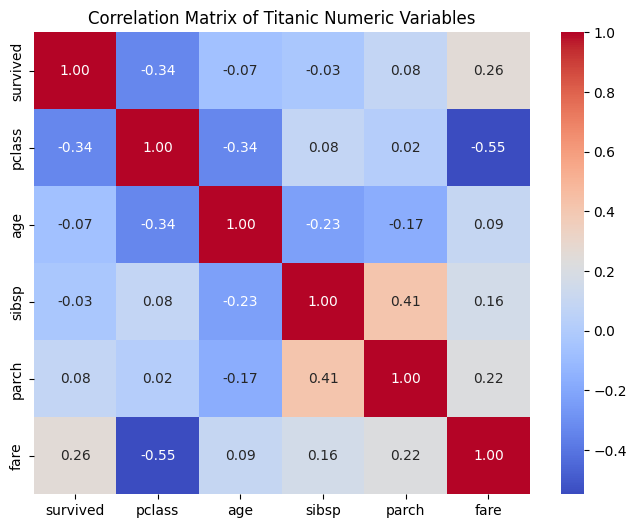

In [ ]:
# Correlation heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Titanic Numeric Variables")
plt.show()

# Find the two strongest correlations

In [ ]:
# Find the two strongest correlations

corr_pairs = (
    corr_matrix
    .where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
)

corr_pairs = corr_pairs.reindex(
    corr_pairs.abs().sort_values(ascending=False).index
)

print("Two strongest correlations:")
print(corr_pairs.head(2))

Two strongest correlations:
pclass  fare    -0.548193
sibsp   parch    0.414542
dtype: float64


### Correlation Interpretation

The two strongest correlations in the selected six-column correlation matrix are between pclass and fare (r = -0.5482) and between sibsp and parch (r = 0.4145). The negative correlation between pclass and fare indicates that higher passenger class numbers are associated with lower fares, while the positive correlation between sibsp and parch indicates that passengers traveling with more siblings or spouses also tend to have more parents or children aboard. These are associations and do not establish causation.

Multivariate analysis — at least 4 charts

Chart 1 — Survival by sex

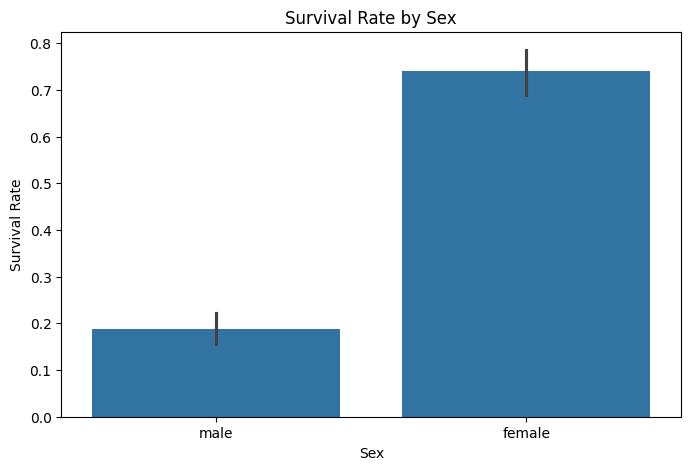

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=clean_df,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")

plt.show()

### Interpretation

The chart compares survival rates between male and female passengers. It shows a clear difference in survival outcomes between the two groups, with female passengers having a higher survival rate than male passengers in this dataset.

Chart 2 — Survival by passenger class

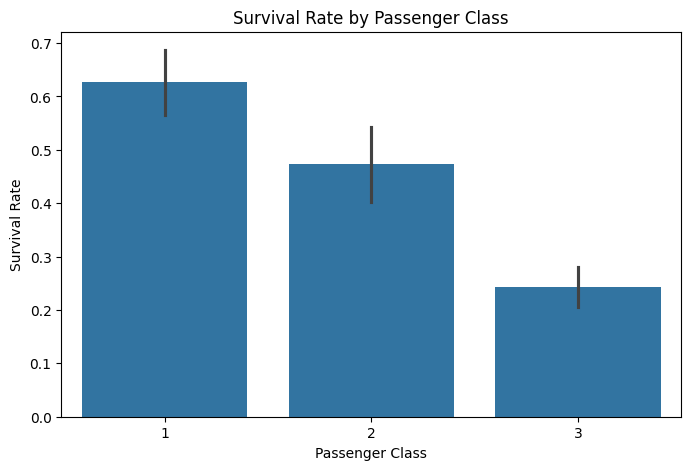

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=clean_df,
    x="pclass",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

### Interpretation

The chart compares survival rates across the three passenger classes. The survival rate differs across classes, showing that passenger class is associated with different survival outcomes in the Titanic dataset.

Chart 3 — Survival by sex and class

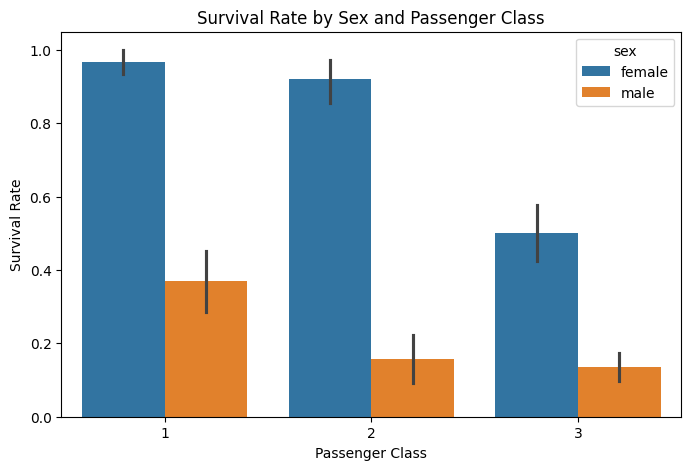

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=clean_df,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

### Interpretation

This chart combines passenger sex and passenger class to examine survival rates more closely. Survival differs across both sex and passenger class, showing that considering the two variables together provides more detailed information than examining either variable separately.

Chart 4 — Age vs Fare by survival

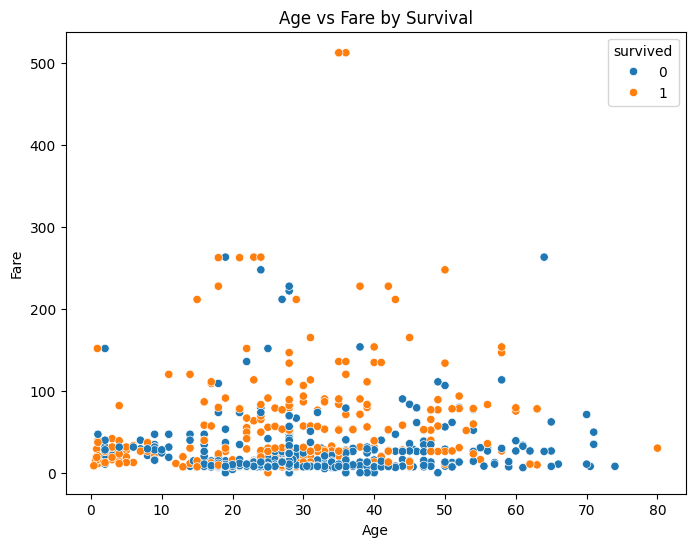

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=clean_df,
    x="age",
    y="fare",
    hue="survived"
)

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

### Interpretation

The scatter plot shows the relationship between passenger age and fare while distinguishing survival outcomes. The points show that survival is distributed across different ages and fare levels, allowing us to examine whether combinations of age and fare appear associated with survival.

Next step: Standardization check
Step 1 — Create a new Code cell

In [ ]:
# Exploratory standardization check

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

age_standardized = scaler.fit_transform(
    clean_df[["age"]]
).flatten()

fare_standardized = scaler.fit_transform(
    clean_df[["fare"]]
).flatten()

print("AGE - Before Standardization")
print("Mean:", clean_df["age"].mean())
print("Std:", clean_df["age"].std())

print("\nAGE - After Standardization")
print("Mean:", age_standardized.mean())
print("Std:", age_standardized.std())

print("\nFARE - Before Standardization")
print("Mean:", clean_df["fare"].mean())
print("Std:", clean_df["fare"].std())

print("\nFARE - After Standardization")
print("Mean:", fare_standardized.mean())
print("Std:", fare_standardized.std())

AGE - Before Standardization
Mean: 29.315151856017994
Std: 12.984932293690774

AGE - After Standardization
Mean: 2.717486278497571e-16
Std: 0.9999999999999999

FARE - Before Standardization
Mean: 32.09668087739032
Std: 49.69750431670801

FARE - After Standardization
Mean: 1.3987061727561027e-16
Std: 1.0


### Standardization Interpretation

Standardization was checked for both age and fare using StandardScaler. After standardization, the mean of age is approximately 0 and its standard deviation is 1. Similarly, the mean of fare is approximately 0 and its standard deviation is 1. This confirms that both variables were transformed to a common standardized scale.

In [ ]:
age_standardized.std()
fare_standardized.std()

np.float64(1.0)

In [ ]:
clean_df.to_csv("titanic.csv", index=False)

print("Cleaned titanic.csv saved successfully.")
print("Cleaned dataset shape:", clean_df.shape)

Cleaned titanic.csv saved successfully.
Cleaned dataset shape: (889, 14)


In [ ]:
# Save the final cleaned dataset
clean_df.to_csv("titanic.csv", index=False)

# Verify the saved file
final_check = pd.read_csv("titanic.csv")

print("Clean dataframe:", clean_df.shape)
print("Saved CSV:", final_check.shape)

Clean dataframe: (889, 14)
Saved CSV: (889, 14)
